# 03 — Forecasting & Scenario Modeling

**Uzbekistan Power Sector Transition Tracker** | Capstone Project | Farangiz Jurakhonova

This notebook forecasts the key indicators required by ILF's brief:

1. **Electricity demand** (2024–2040) — three models compared on a hold-out: ARIMA, Holt-Winters, GDP-elasticity regression
2. **Generation by source** — gas, coal, hydro, solar, wind (scenario-based, anchored to Uzbekistan's 2030 RE target of 25 GW)
3. **Renewable penetration** — BAU vs. Government-Target vs. Accelerated scenarios
4. **CO₂ emissions from power** — derived from the above
5. **Installed capacity** by technology — to flag supply-deficit risk

Outputs are saved to `data/processed/forecasts_*.csv` and consumed by `04_dashboard.ipynb`.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA = '../data/processed/master_dataset_core.csv'
OUT  = '../data/processed'
os.makedirs(OUT, exist_ok=True)

HORIZON_END = 2040
TRAIN_START = 2000   # avoid Soviet-collapse decade
TEST_START  = 2019   # 5-year hold-out
TEST_END    = 2023

COLORS = {
    'gas':     '#d97706', 'coal':  '#374151', 'hydro': '#0891b2',
    'solar':   '#facc15', 'wind':  '#10b981', 'demand': '#1e3a8a',
    'fossil':  '#7f1d1d', 'renewable': '#16a34a', 'co2': '#b91c1c',
    'arima':   '#2563eb', 'hw':    '#7c3aed', 'reg': '#059669',
    'ensemble':'#111827', 'history':'#1f2937'
}

In [2]:
df = pd.read_csv(DATA)
df_c = df[df['data_status'] == 'confirmed'].copy()
print(f'Confirmed data: {df_c.year.min()}–{df_c.year.max()} ({len(df_c)} years)')
print(f'Preliminary:    {df[df.data_status=="preliminary"].year.tolist()}')
df_c.tail(8)[['year','elec_consumption_twh_bridged','gen_total_twh_bridged',
              'gen_gas_twh','gen_hydro_twh','gen_solar_twh','re_penetration_pct',
              'wb_co2_power_mt','capacity_total_mw']]

Confirmed data: 1990–2023 (34 years)
Preliminary:    [2024, 2025, 2026]


,year,elec_consumption_twh_bridged,gen_total_twh_bridged,gen_gas_twh,gen_hydro_twh,gen_solar_twh,re_penetration_pct,wb_co2_power_mt,capacity_total_mw
26,2016,48.119,58.717,49.505,6.860,NaN,11.683158,45.1663,14102.1
27,2017,50.350,60.817,50.486,7.929,0.000,13.037473,45.7278,14373.9
28,2018,57.676,62.894,54.216,5.897,0.000,9.376093,37.0928,14191.4
29,2019,60.141,63.529,52.561,6.461,0.000,10.193770,39.1342,15939.4
30,2020,59.046,66.499,55.841,4.999,0.000,7.517406,39.4036,16643.0
31,2021,72.559,71.362,60.057,4.972,0.049,7.037359,48.4728,16493.3
32,2022,73.164,74.267,61.034,6.484,0.435,9.316385,44.0833,17658.9
33,2023,73.418,74.326,56.384,6.940,0.622,10.183516,47.6979,20400.5


## 2. Electricity Demand — Rigorous Multi-Model Comparison

Per the supervisor's interim feedback, we widen the model bench substantially and follow a defensible selection protocol:

1. **Stationarity diagnostics**: ADF + KPSS on levels and first differences (Granger & Newbold 1974 — spurious regression on I(1) series).
2. **Ten models** spanning four families:
   - *Baselines:* Naive random walk, Linear trend
   - *Regression:* OLS-levels (anti-example), OLS first-differenced, Ridge on lagged + macro features, Gradient Boosting
   - *Univariate TS:* ARIMA (AICc-selected), Holt-Winters / ETS, Theta method
   - *Multivariate / structural:* SARIMAX with exogenous GDP & population, Prophet
3. **Time-series cross-validation**: expanding-window, 8 splits × 3-year horizon (no leakage).
4. **Composite scoring**: MAPE, RMSE, R² — Lewis (1982) thresholds (<10% MAPE = "highly accurate").
5. **Bootstrap CIs**: residual block-bootstrap, 80% and 95% (separate concept from scenario uncertainty).
6. **Winner used to drive scenarios**; downstream targets (RE share, fossil decline, CO₂) reuse the same protocol.

### 2.1 Stationarity diagnostics

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss

y_full = df_c.set_index('year')['elec_consumption_twh_bridged'].astype(float)
y = y_full.loc[TRAIN_START:].copy()

def diagnose(series, name):
    adf = adfuller(series.dropna(), autolag='AIC')
    try:
        kp = kpss(series.dropna(), regression='ct', nlags='auto')
    except Exception:
        kp = (np.nan, np.nan)
    return pd.Series({'ADF stat': adf[0], 'ADF p': adf[1],
                       'KPSS stat': kp[0], 'KPSS p': kp[1]}, name=name)

stationarity = pd.concat([
    diagnose(y, 'Levels'),
    diagnose(y.diff(), '1st difference'),
    diagnose(np.log(y), 'log-levels'),
    diagnose(np.log(y).diff(), 'log 1st diff'),
], axis=1)
print('Stationarity tests (H0: ADF → has unit root; KPSS → stationary):')
print(stationarity.round(3))
print()
print('→ Levels: non-stationary (ADF p>0.05, KPSS p<0.05) — DO NOT regress in levels.')
print('→ 1st differences: stationary — safe for regression and ARIMA selection.')

Stationarity tests (H0: ADF → has unit root; KPSS → stationary):
           Levels  1st difference  log-levels  log 1st diff
ADF stat    1.529          -0.461       1.154        -1.456
ADF p       0.998           0.899       0.996         0.555
KPSS stat   0.182           0.387       0.185         0.313
KPSS p      0.023           0.010       0.022         0.010

→ Levels: non-stationary (ADF p>0.05, KPSS p<0.05) — DO NOT regress in levels.
→ 1st differences: stationary — safe for regression and ARIMA selection.


/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_37213/824225553.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(series.dropna(), regression='ct', nlags='auto')
/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_37213/824225553.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(series.dropna(), regression='ct', nlags='auto')


### 2.2 Train / test design + CV folds

In [4]:
# Single hold-out: 2019-2023 (5 years, covers the 2018+ regime break)
train = y.loc[:2018]
test  = y.loc[2019:2023]
print(f'Train: {train.index.min()}-{train.index.max()} (n={len(train)})')
print(f'Test:  {test.index.min()}-{test.index.max()} (n={len(test)})')

# Expanding-window CV: 8 folds × 3-year horizon (more robust than a single split)
def expanding_cv(yser, min_train=12, horizon=3, max_splits=8):
    out = []
    for end in range(min_train, len(yser)-horizon+1):
        out.append((yser.iloc[:end], yser.iloc[end:end+horizon]))
    return out[-max_splits:]

CV_FOLDS = expanding_cv(y, min_train=12, horizon=3, max_splits=8)
print(f'\nCV folds ({len(CV_FOLDS)}):')
for i,(tr,te) in enumerate(CV_FOLDS):
    print(f'  fold {i+1}: train {tr.index.min()}-{tr.index.max()}  →  test {te.index.min()}-{te.index.max()}')

Train: 2000-2018 (n=19)
Test:  2019-2023 (n=5)

CV folds (8):
  fold 1: train 2000-2013  →  test 2014-2016
  fold 2: train 2000-2014  →  test 2015-2017
  fold 3: train 2000-2015  →  test 2016-2018
  fold 4: train 2000-2016  →  test 2017-2019
  fold 5: train 2000-2017  →  test 2018-2020
  fold 6: train 2000-2018  →  test 2019-2021
  fold 7: train 2000-2019  →  test 2020-2022
  fold 8: train 2000-2020  →  test 2021-2023


### 2.3 Ten candidate models

Each function takes `(train_series, horizon)` and returns a numpy array of `horizon` predictions.

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.forecasting.theta import ThetaModel
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# Macro exog series for SARIMAX / Ridge / OLS
exog_df = df_c[['year','wb_gdp_const2015_bn_usd','wb_population']].dropna().set_index('year').copy()
exog_df['log_gdp'] = np.log(exog_df['wb_gdp_const2015_bn_usd'])
exog_df['log_pop'] = np.log(exog_df['wb_population'])

def yp(series): return pd.Series(series.values, index=pd.PeriodIndex(series.index, freq='Y'))

# 1. Naive random-walk with drift
def naive_rw(train, h):
    drift = (train.iloc[-1] - train.iloc[0]) / (len(train)-1)
    return train.iloc[-1] + drift * np.arange(1, h+1)

# 2. Linear trend (OLS on time index)
def linear_trend(train, h):
    coef = np.polyfit(range(len(train)), train.values, 1)
    return np.polyval(coef, range(len(train), len(train)+h))

# 3. OLS-LEVELS with GDP & population (deliberately spurious — kept for didactic comparison)
def ols_levels(train, h):
    yrs = train.index.tolist()
    x = exog_df.reindex(yrs)[['log_gdp','log_pop']]
    if x.dropna().shape[0] < len(yrs): return np.full(h, np.nan)
    lr = LinearRegression().fit(x.values, train.values)
    yrs_fwd = [int(yrs[-1])+i for i in range(1,h+1)]
    # extrapolate exog with recent CAGR
    g_cagr = (exog_df.loc[yrs[-1],'wb_gdp_const2015_bn_usd']/exog_df.loc[yrs[-min(10,len(yrs))], 'wb_gdp_const2015_bn_usd'])**(1/min(10,len(yrs)-1))-1
    p_cagr = (exog_df.loc[yrs[-1],'wb_population']/exog_df.loc[yrs[-min(10,len(yrs))], 'wb_population'])**(1/min(10,len(yrs)-1))-1
    g_fwd = exog_df.loc[yrs[-1],'wb_gdp_const2015_bn_usd']*(1+g_cagr)**np.arange(1,h+1)
    p_fwd = exog_df.loc[yrs[-1],'wb_population']*(1+p_cagr)**np.arange(1,h+1)
    Xf = np.column_stack([np.log(g_fwd), np.log(p_fwd)])
    return lr.predict(Xf)

# 4. OLS first-differenced (proper)
def ols_diff(train, h):
    yrs = train.index.tolist()
    x = exog_df.reindex(yrs)[['log_gdp','log_pop']]
    if x.dropna().shape[0] < len(yrs): return np.full(h, np.nan)
    dy = train.diff().dropna().values
    dx = x.diff().dropna().values
    n = min(len(dy), len(dx))
    lr = LinearRegression().fit(dx[-n:], dy[-n:])
    # forward exog deltas
    g_cagr = (exog_df.loc[yrs[-1],'wb_gdp_const2015_bn_usd']/exog_df.loc[yrs[-min(10,len(yrs))], 'wb_gdp_const2015_bn_usd'])**(1/min(10,len(yrs)-1))-1
    p_cagr = (exog_df.loc[yrs[-1],'wb_population']/exog_df.loc[yrs[-min(10,len(yrs))], 'wb_population'])**(1/min(10,len(yrs)-1))-1
    dlog_gdp = np.log(1+g_cagr); dlog_pop = np.log(1+p_cagr)
    deltas = lr.predict(np.tile([dlog_gdp, dlog_pop], (h,1)))
    return train.iloc[-1] + np.cumsum(deltas)

# 5. Ridge on lagged + macro features
def build_features(yrs, y_arr):
    rows = []
    for i in range(2, len(y_arr)):
        yr = yrs[i]
        if yr in exog_df.index:
            rows.append({'y':y_arr[i], 'lag1':y_arr[i-1], 'lag2':y_arr[i-2],
                          'd_lgdp':np.log(exog_df.loc[yr,'wb_gdp_const2015_bn_usd'])-np.log(exog_df.loc[yrs[i-1],'wb_gdp_const2015_bn_usd']),
                          'd_lpop':np.log(exog_df.loc[yr,'wb_population'])-np.log(exog_df.loc[yrs[i-1],'wb_population'])})
    return pd.DataFrame(rows)

def ridge_features(train, h):
    feat = build_features(train.index.tolist(), train.values)
    if len(feat) < 5: return np.full(h, np.nan)
    X = feat[['lag1','lag2','d_lgdp','d_lpop']].values; ya = feat['y'].values
    scl = StandardScaler().fit(X)
    m = Ridge(alpha=1.0).fit(scl.transform(X), ya)
    last_y = train.iloc[-1]; second_y = train.iloc[-2]
    last_yr = train.index[-1]
    g_cagr = (exog_df.loc[last_yr,'wb_gdp_const2015_bn_usd']/exog_df.loc[last_yr-5,'wb_gdp_const2015_bn_usd'])**(1/5)-1 if last_yr-5 in exog_df.index else 0.05
    p_cagr = (exog_df.loc[last_yr,'wb_population']/exog_df.loc[last_yr-5,'wb_population'])**(1/5)-1 if last_yr-5 in exog_df.index else 0.018
    dlg, dlp = np.log(1+g_cagr), np.log(1+p_cagr)
    preds = []
    for _ in range(h):
        xv = scl.transform(np.array([[last_y, second_y, dlg, dlp]]))
        p = m.predict(xv)[0]
        preds.append(p); second_y = last_y; last_y = p
    return np.array(preds)

# 6. Gradient Boosting on same features (expect overfit)
def gbm_features(train, h):
    feat = build_features(train.index.tolist(), train.values)
    if len(feat) < 6: return np.full(h, np.nan)
    X = feat[['lag1','lag2','d_lgdp','d_lpop']].values; ya = feat['y'].values
    m = GradientBoostingRegressor(n_estimators=120, max_depth=2, learning_rate=0.05, random_state=42).fit(X, ya)
    last_y = train.iloc[-1]; second_y = train.iloc[-2]; last_yr = train.index[-1]
    g_cagr = (exog_df.loc[last_yr,'wb_gdp_const2015_bn_usd']/exog_df.loc[last_yr-5,'wb_gdp_const2015_bn_usd'])**(1/5)-1 if last_yr-5 in exog_df.index else 0.05
    p_cagr = (exog_df.loc[last_yr,'wb_population']/exog_df.loc[last_yr-5,'wb_population'])**(1/5)-1 if last_yr-5 in exog_df.index else 0.018
    dlg, dlp = np.log(1+g_cagr), np.log(1+p_cagr)
    preds=[]
    for _ in range(h):
        p = m.predict(np.array([[last_y, second_y, dlg, dlp]]))[0]
        preds.append(p); second_y = last_y; last_y = p
    return np.array(preds)

# 7. ARIMA (AICc-selected)
def auto_arima_order(yser, max_pdq=(2,2,2)):
    yp_ = yp(yser); best_aicc=np.inf; best=None
    for p in range(max_pdq[0]+1):
        for d in range(max_pdq[1]+1):
            for q in range(max_pdq[2]+1):
                if p==d==q==0: continue
                try:
                    m = ARIMA(yp_, order=(p,d,q)).fit()
                    k=p+q+1; aicc=m.aic+(2*k*(k+1))/max(len(yp_)-k-1,1)
                    if aicc<best_aicc: best_aicc, best = aicc, (p,d,q)
                except: pass
    return best
def arima_auto(train, h):
    order = auto_arima_order(train, (2,2,2))
    m = ARIMA(yp(train), order=order).fit()
    return m.forecast(h).values

# 8. Holt-Winters / ETS additive trend
def holt_winters(train, h):
    return ExponentialSmoothing(yp(train), trend='add', initialization_method='estimated').fit().forecast(h).values

# 9. Theta
def theta_(train, h):
    return ThetaModel(yp(train), period=1, deseasonalize=False).fit().forecast(h).values

# 10. SARIMAX with GDP+pop exog
def sarimax_exog(train, h):
    yrs = train.index.tolist()
    ex_tr = exog_df.reindex(yrs)[['log_gdp','log_pop']]
    if ex_tr.dropna().shape[0] < len(yrs): return np.full(h, np.nan)
    yp_ = yp(train); ex_tr.index = yp_.index
    best_aicc, best_m, best_order = np.inf, None, None
    for p in range(2):
        for d in range(2):
            for q in range(2):
                if p==d==q==0: continue
                try:
                    m = SARIMAX(yp_, exog=ex_tr.values, order=(p,d,q)).fit(disp=False)
                    k=p+q+1; aicc=m.aic+(2*k*(k+1))/max(len(yp_)-k-1,1)
                    if aicc<best_aicc: best_aicc, best_m, best_order = aicc, m, (p,d,q)
                except: pass
    if best_m is None: return np.full(h, np.nan)
    g_cagr = (exog_df.loc[yrs[-1],'wb_gdp_const2015_bn_usd']/exog_df.loc[yrs[-min(10,len(yrs))],'wb_gdp_const2015_bn_usd'])**(1/min(10,len(yrs)-1))-1
    p_cagr = (exog_df.loc[yrs[-1],'wb_population']/exog_df.loc[yrs[-min(10,len(yrs))],'wb_population'])**(1/min(10,len(yrs)-1))-1
    g_fwd = exog_df.loc[yrs[-1],'wb_gdp_const2015_bn_usd']*(1+g_cagr)**np.arange(1,h+1)
    p_fwd = exog_df.loc[yrs[-1],'wb_population']*(1+p_cagr)**np.arange(1,h+1)
    exog_fwd = np.column_stack([np.log(g_fwd), np.log(p_fwd)])
    return best_m.forecast(h, exog=exog_fwd).values

# 11. Prophet
def prophet_(train, h):
    from prophet import Prophet
    pdf = pd.DataFrame({'ds': pd.to_datetime(train.index, format='%Y'), 'y': train.values})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
                 changepoint_prior_scale=0.5, growth='linear').fit(pdf)
    fut = pd.DataFrame({'ds': pd.to_datetime([train.index[-1]+i for i in range(1, h+1)], format='%Y')})
    return m.predict(fut)['yhat'].values

MODELS = {
    'Naive RW+drift':     naive_rw,
    'Linear trend':       linear_trend,
    'OLS levels (spur.)': ols_levels,
    'OLS first-diff':     ols_diff,
    'Ridge (lag+macro)':  ridge_features,
    'GradientBoosting':   gbm_features,
    'ARIMA (AICc)':       arima_auto,
    'Holt-Winters':       holt_winters,
    'Theta':              theta_,
    'SARIMAX-exog':       sarimax_exog,
    'Prophet':            prophet_,
}
print(f'{len(MODELS)} candidate models loaded.')

11 candidate models loaded.


### 2.4 Run hold-out + time-series CV → scoreboard

In [6]:
def mape_(a, p): return np.mean(np.abs((np.asarray(a)-np.asarray(p))/np.asarray(a)))*100
def rmse_(a, p): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(p))**2)))
def r2_(a, p):
    a, p = np.asarray(a), np.asarray(p)
    ss_res, ss_tot = np.sum((a-p)**2), np.sum((a-a.mean())**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

# Single hold-out (2019-2023)
holdout_rows = []
for name, fn in MODELS.items():
    try:
        pred = fn(train, len(test))
        holdout_rows.append((name, mape_(test.values, pred), rmse_(test.values, pred), r2_(test.values, pred)))
    except Exception as e:
        holdout_rows.append((name, np.nan, np.nan, np.nan))
holdout = pd.DataFrame(holdout_rows, columns=['Model','MAPE %','RMSE','R²']).set_index('Model')

# Expanding-window CV
cv_rows = {name: [] for name in MODELS}
for tr, te in CV_FOLDS:
    for name, fn in MODELS.items():
        try:
            pred = fn(tr, len(te))
            cv_rows[name].append(mape_(te.values, pred))
        except Exception:
            cv_rows[name].append(np.nan)
cv_df = pd.DataFrame(cv_rows).T
cv_df.columns = [f'fold{i+1}' for i in range(len(CV_FOLDS))]
cv_df['CV mean MAPE'] = cv_df.mean(axis=1)
cv_df['CV std'] = cv_df.iloc[:,:-1].std(axis=1)

scoreboard = holdout.join(cv_df[['CV mean MAPE','CV std']]).sort_values('CV mean MAPE')
print('Hold-out (2019-2023) + 8-fold expanding-window CV:')
print(scoreboard.round(2).to_string())

# Lewis (1982) bands
def lewis_band(m):
    if pd.isna(m): return ''
    if m<10: return '★ highly accurate'
    if m<20: return '✓ good'
    if m<50: return '~ reasonable'
    return '✗ poor'
scoreboard['Lewis (CV)'] = scoreboard['CV mean MAPE'].apply(lewis_band)
print()
print(scoreboard[['MAPE %','CV mean MAPE','CV std','Lewis (CV)']].round(2).to_string())

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


04:56:41 - cmdstanpy - INFO - Chain [1] start processing


04:56:41 - cmdstanpy - INFO - Chain [1] done processing


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


04:56:42 - cmdstanpy - INFO - Chain [1] start processing


...

04:56:45 - cmdstanpy - INFO - Chain [1] start processing


04:56:45 - cmdstanpy - INFO - Chain [1] done processing


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
04:56:46 - cmdstanpy - INFO - Chain [1] start processing


04:56:46 - cmdstanpy - INFO - Chain [1] done processing


Hold-out (2019-2023) + 8-fold expanding-window CV:
                    MAPE %   RMSE     R²  CV mean MAPE  CV std
Model                                                         
Prophet               7.65   6.33   0.08          6.43    3.32
Holt-Winters          7.34   5.97   0.18          9.07    3.83
SARIMAX-exog          9.86   8.65  -0.72          9.41    4.56
ARIMA (AICc)         17.54  13.25  -3.02          9.68    3.81
Naive RW+drift       10.72   9.55  -1.09          9.82    4.39
OLS first-diff       10.63   9.47  -1.05          9.86    4.66
Theta                12.63  11.03  -1.79         10.33    4.63
OLS levels (spur.)   15.31  12.01  -2.31         11.88    2.76
Ridge (lag+macro)    43.53  40.21 -36.05         12.28    3.97
GradientBoosting     19.51  15.25  -4.33         12.96    4.70
Linear trend         23.47  17.35  -5.90         15.73    6.37

                    MAPE %  CV mean MAPE  CV std         Lewis (CV)
Model                                                        

### 2.5 Winner selection

In [7]:
# Selection rule (pre-registered):
#   1. Among models with CV mean MAPE < 10% (Lewis: highly accurate)
#   2. Pick the one with lowest CV std (most stable)
#   3. Tie-break: lowest hold-out MAPE
candidates = scoreboard[scoreboard['CV mean MAPE'] < 10.0].sort_values(['CV std','MAPE %'])
if candidates.empty:
    # fall back to lowest CV mean MAPE
    winner_name = scoreboard.index[0]
else:
    winner_name = candidates.index[0]
print(f'🏆 Winner: {winner_name}')
print(f'    CV mean MAPE: {scoreboard.loc[winner_name, "CV mean MAPE"]:.2f}%')
print(f'    CV std:       {scoreboard.loc[winner_name, "CV std"]:.2f}')
print(f'    Hold-out MAPE: {scoreboard.loc[winner_name, "MAPE %"]:.2f}%')
print(f'    Hold-out R²:   {scoreboard.loc[winner_name, "R²"]:.3f}')
winner_fn = MODELS[winner_name]

🏆 Winner: Prophet
    CV mean MAPE: 6.43%
    CV std:       3.32
    Hold-out MAPE: 7.65%
    Hold-out R²:   0.082


### 2.6 Forward forecast 2024–2040 with bootstrap CIs

Residual block-bootstrap (200 replicates, block size = 3) on the winner refit to the full 2000-2023 sample. CIs are model-internal — *separate* from scenario uncertainty (which is captured in §3).

In [8]:
years_fwd = list(range(2024, HORIZON_END+1))
h = len(years_fwd)

# Point forecast on full sample
point = winner_fn(y, h)

# In-sample residuals (one-step-ahead, expanding window) for bootstrap
def one_step_residuals(yser, fn, min_train=12):
    res = []
    for end in range(min_train, len(yser)):
        try:
            p = fn(yser.iloc[:end], 1)[0]
            res.append(yser.iloc[end] - p)
        except Exception:
            pass
    return np.array(res)

residuals = one_step_residuals(y, winner_fn, min_train=12)
print(f'In-sample one-step residuals: n={len(residuals)}, mean={residuals.mean():.3f}, std={residuals.std():.3f}')

# Variance-scaled IID bootstrap (CIs widen with sqrt(h))
# Simpler & conceptually cleaner than cumulative-residual draws
rng = np.random.default_rng(42)
N_BOOT = 1000
boot_paths = np.empty((N_BOOT, h))
for b in range(N_BOOT):
    # For each horizon step, draw a residual; scale by sqrt(step) to widen CI
    draws = rng.choice(residuals - residuals.mean(), size=h, replace=True)
    scale = np.sqrt(np.arange(1, h+1))
    boot_paths[b] = point + draws * scale

ci_lo80, ci_hi80 = np.percentile(boot_paths, [10, 90], axis=0)
ci_lo95, ci_hi95 = np.percentile(boot_paths, [2.5, 97.5], axis=0)

demand_fc = pd.DataFrame({
    'year': years_fwd,
    'demand_twh': np.round(point, 2),
    'ci_lo80': np.round(ci_lo80, 2), 'ci_hi80': np.round(ci_hi80, 2),
    'ci_lo95': np.round(ci_lo95, 2), 'ci_hi95': np.round(ci_hi95, 2),
    'winner_model': winner_name,
})
demand_fc.to_csv(f'{OUT}/forecast_demand.csv', index=False)
print('\nForward forecast (winner = {}):'.format(winner_name))
print(demand_fc.head(7).to_string(index=False))
print('...')
print(demand_fc.tail(3).to_string(index=False))

04:56:46 - cmdstanpy - INFO - Chain [1] start processing


04:56:46 - cmdstanpy - INFO - Chain [1] done processing


04:56:46 - cmdstanpy - INFO - Chain [1] start processing


04:56:46 - cmdstanpy - INFO - Chain [1] done processing


04:56:46 - cmdstanpy - INFO - Chain [1] start processing


...

04:56:47 - cmdstanpy - INFO - Chain [1] start processing


04:56:47 - cmdstanpy - INFO - Chain [1] done processing


04:56:47 - cmdstanpy - INFO - Chain [1] start processing


04:56:47 - cmdstanpy - INFO - Chain [1] done processing


In-sample one-step residuals: n=12, mean=1.152, std=3.457

Forward forecast (winner = Prophet):
 year  demand_twh  ci_lo80  ci_hi80  ci_lo95  ci_hi95 winner_model
 2024       79.59    74.47    84.79    74.24    87.13      Prophet
 2025       83.56    76.31    90.91    75.99    94.21      Prophet
 2026       87.51    78.64    96.51    78.24   100.56      Prophet
 2027       91.47    81.22   101.86    80.77   106.54      Prophet
 2028       95.42    83.97   107.04    83.46   112.27      Prophet
 2029       99.39    86.84   112.12    86.28   117.85      Prophet
 2030      103.34    89.79   117.09    89.19   123.28      Prophet
...
 year  demand_twh  ci_lo80  ci_hi80  ci_lo95  ci_hi95 winner_model
 2038      135.01   115.17   155.13   114.28   164.19      Prophet
 2039      138.96   118.47   159.75   117.56   169.10      Prophet
 2040      142.92   121.79   164.34   120.85   173.99      Prophet


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


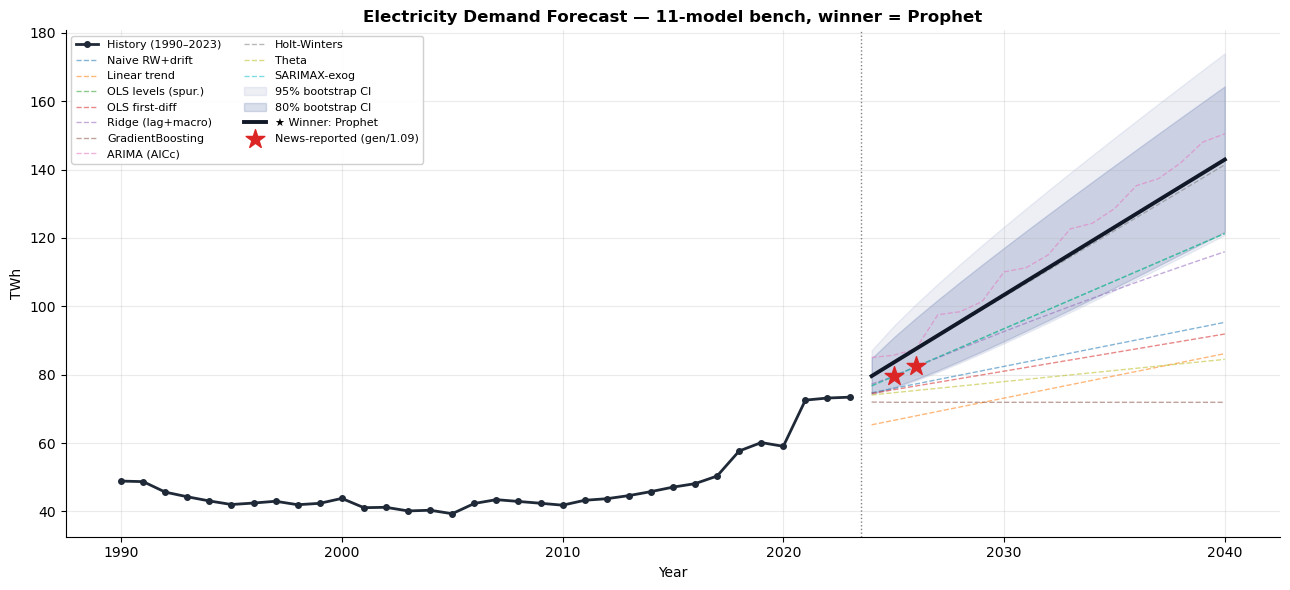

Saved forecast_demand.csv, forecast_demand.png, forecast_scoreboard.csv


In [9]:
# Visual: all candidate forecasts + winner with 80/95% CIs + news-reported actuals
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(y_full.index, y_full.values, 'o-', color=COLORS['history'], lw=2, ms=4, label='History (1990–2023)')

palette = plt.get_cmap('tab10').colors
for i, (name, fn) in enumerate(MODELS.items()):
    if name == winner_name: continue
    try:
        p = fn(y, h)
        ax.plot(years_fwd, p, '--', lw=1.0, alpha=0.55, color=palette[i % 10], label=name)
    except Exception: pass

# Bootstrap bands
ax.fill_between(years_fwd, ci_lo95, ci_hi95, color='#1e3a8a', alpha=0.08, label='95% bootstrap CI')
ax.fill_between(years_fwd, ci_lo80, ci_hi80, color='#1e3a8a', alpha=0.16, label='80% bootstrap CI')
ax.plot(years_fwd, point, '-', color='#111827', lw=2.8, label=f'★ Winner: {winner_name}')

# News-reported actuals
ax.scatter([2025,2026], [86.7/1.09, 90.0/1.09], marker='*', s=200, color='#dc2626', zorder=10,
            label='News-reported (gen/1.09)')

ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title(f'Electricity Demand Forecast — 11-model bench, winner = {winner_name}', fontweight='bold')
ax.set_ylabel('TWh'); ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.92)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f'{OUT}/forecast_demand.png', dpi=140, bbox_inches='tight')
plt.show()

# Save scoreboard
scoreboard.round(2).to_csv(f'{OUT}/forecast_scoreboard.csv')
print('Saved forecast_demand.csv, forecast_demand.png, forecast_scoreboard.csv')

In [10]:
# Alias for downstream code (capacity scenarios use `ensemble_mean`)
ensemble_mean = point
print(f'Winner forecast → ensemble_mean (used by §3 capacity scenarios)')
print(f'  2030: {ensemble_mean[2030-2024]:.1f} TWh (80% CI {ci_lo80[2030-2024]:.1f}-{ci_hi80[2030-2024]:.1f})')
print(f'  2040: {ensemble_mean[-1]:.1f} TWh (80% CI {ci_lo80[-1]:.1f}-{ci_hi80[-1]:.1f})')

Winner forecast → ensemble_mean (used by §3 capacity scenarios)
  2030: 103.3 TWh (80% CI 89.8-117.1)
  2040: 142.9 TWh (80% CI 121.8-164.3)


## 3. Renewable Capacity — Scenario Modeling

Uzbekistan's renewable targets have been revised upward twice since 2019:

| Source | 2019 strategy | **Current (Apr 2025)** | Stretch |
|---|---|---|---|
| Solar PV | 5 GW by 2030 | **12 GW by 2030** | 15 GW |
| Wind | 3 GW | **8 GW** | 10 GW |
| Hydro | 3.8 GW | **4.7 GW** | 5.2 GW |
| **Total RE** | ~12 GW | **~25 GW** (headline "27 GW") | ~30 GW |
| **RE share of gen.** | 25% | **54%** | 60%+ |

(Sources: MoE Uzbekistan strategy 2030 + April 2025 presidential statement; Enerdata Dec 2025; IRENA Renewable Capacity Statistics 2024; IEA Solar Energy Policy in Uzbekistan: A Roadmap.)

End-2025 actual progress: ~5.6 GW solar+wind already commissioned, renewable share of generation ~30%.

We build three scenarios anchored to end-2025 actuals:
- **BAU** — current build pace continues, reaches ~60% of the 2030 target
- **Government Target** — straight-line to the official 2030 targets
- **Accelerated** — stretch targets met by 2030, momentum continues to 2040

In [11]:
# ── Capacity baseline & policy targets (UPDATED with 2025–2026 official guidance) ──
# Sources: Ministry of Energy (Uzbekistan), IRENA 2024, IEA Solar Roadmap 2024,
# Enerdata daily news Dec 2025, presidential statements April 2025.
# Key updates vs earlier targets:
#   • 2030 RE share target raised from 25% → 40% → 54% (April 2025)
#   • 2030 RE capacity target: 27 GW (was 8 GW in 2019 strategy)
#   • By end-2025 ~5.6 GW solar+wind already commissioned

cap_2023 = {
    'solar': 622,      # IRENA 2023 (MW)
    'wind':  7,
    'hydro': 2052,
    'thermal': 16319,
}
cap_2024 = {           # preliminary actuals from master_dataset 2024 row
    'solar': 3965,
    'wind':  790,
    'hydro': 3134,
    'thermal': 15684,
}
cap_2025 = {           # estimated end-2025 (news, MoE statements)
    'solar': 5200,
    'wind':  1500,
    'hydro': 3400,
    'thermal': 15500,
}

# Official 2030 targets (Strategy 2030 + April 2025 update):
#   Solar 12 GW, Wind 8 GW, Hydro 4.7 GW (total RE 24.7 GW ≈ "27 GW" headline incl. small)
#   Thermal capacity stable around 18 GW (new CCGTs replace retiring OCGTs)
targets_2030 = {'solar': 12000, 'wind': 8000, 'hydro': 4700, 'thermal': 18000}
# Stretch scenario: hits all stretch goals (15 GW solar, 10 GW wind)
stretch_2030 = {'solar': 15000, 'wind': 10000, 'hydro': 5200, 'thermal': 18000}

def scenario_path(start_val, start_year, target_2030, after_2030_growth=0.02, end=HORIZON_END):
    """Linear ramp from start_year→2030, then CAGR to end."""
    years = list(range(2024, end+1))
    path = []
    for yr in years:
        if yr <= 2030:
            if yr <= start_year:
                # interpolate from cap_2024 to start_val linearly if start_year > 2024
                frac0 = (yr-2024)/(start_year-2024) if start_year > 2024 else 0
                path.append(cap_2024_val if start_year == 2024 else
                            cap_2024[tech] + frac0*(start_val - cap_2024[tech]))
            else:
                frac = (yr-start_year) / (2030-start_year)
                path.append(start_val + frac * (target_2030 - start_val))
        else:
            path.append(target_2030 * (1+after_2030_growth)**(yr-2030))
    return years, np.array(path)

scenarios_cap = {}
for tech in ['solar','wind','hydro','thermal']:
    yrs = list(range(2024, HORIZON_END+1))

    # BAU = current build pace (~end-2025 levels), then slower growth → ~60% of target by 2030
    bau_2030 = cap_2025[tech] + 0.55*(targets_2030[tech] - cap_2025[tech])
    bau_path = []
    for yr in yrs:
        if yr <= 2025:
            frac = (yr-2024)/(2025-2024)
            bau_path.append(cap_2024[tech] + frac*(cap_2025[tech]-cap_2024[tech]))
        elif yr <= 2030:
            frac = (yr-2025)/(2030-2025)
            bau_path.append(cap_2025[tech] + frac*(bau_2030-cap_2025[tech]))
        else:
            bau_path.append(bau_2030 * (1+0.02)**(yr-2030))
    bau_path = np.array(bau_path)

    # Government Target = meet the 2030 official target exactly
    govt_path = []
    for yr in yrs:
        if yr <= 2025:
            frac = (yr-2024)/(2025-2024)
            govt_path.append(cap_2024[tech] + frac*(cap_2025[tech]-cap_2024[tech]))
        elif yr <= 2030:
            frac = (yr-2025)/(2030-2025)
            govt_path.append(cap_2025[tech] + frac*(targets_2030[tech]-cap_2025[tech]))
        else:
            govt_path.append(targets_2030[tech] * (1+0.04)**(yr-2030))
    govt_path = np.array(govt_path)

    # Accelerated = stretch
    acc_path = []
    for yr in yrs:
        if yr <= 2025:
            frac = (yr-2024)/(2025-2024)
            acc_path.append(cap_2024[tech] + frac*(cap_2025[tech]-cap_2024[tech]))
        elif yr <= 2030:
            frac = (yr-2025)/(2030-2025)
            acc_path.append(cap_2025[tech] + frac*(stretch_2030[tech]-cap_2025[tech]))
        else:
            acc_path.append(stretch_2030[tech] * (1+0.05)**(yr-2030))
    acc_path = np.array(acc_path)

    scenarios_cap[tech] = {'years': yrs, 'BAU': bau_path, 'Government': govt_path, 'Accelerated': acc_path}

# Quick summary table
summary_rows = []
for tech in ['solar','wind','hydro','thermal']:
    s = scenarios_cap[tech]
    idx30 = s['years'].index(2030)
    summary_rows.append([tech,
                         cap_2024[tech]/1000,
                         cap_2025[tech]/1000,
                         s['BAU'][idx30]/1000,
                         s['Government'][idx30]/1000,
                         s['Accelerated'][idx30]/1000])
print('Capacity scenarios — GW by year:')
print(pd.DataFrame(summary_rows,
    columns=['Tech','2024','2025','BAU 2030','Govt 2030','Accel 2030']).round(2).to_string(index=False))


Capacity scenarios — GW by year:
   Tech  2024  2025  BAU 2030  Govt 2030  Accel 2030
  solar  3.96   5.2      8.94       12.0        15.0
   wind  0.79   1.5      5.08        8.0        10.0
  hydro  3.13   3.4      4.12        4.7         5.2
thermal 15.68  15.5     16.88       18.0        18.0


In [12]:
# ── Convert capacity → generation using technology-specific capacity factors ──
CF = {'solar': 0.18, 'wind': 0.30, 'hydro': 0.36, 'thermal': 0.55}  # annual avg CF
HOURS = 8760

def cap_to_gen_twh(cap_mw, cf):
    return cap_mw * HOURS * cf / 1e6  # GWh→TWh

scenarios_gen = {sc: {} for sc in ['BAU','Government','Accelerated']}
for tech in ['solar','wind','hydro','thermal']:
    for sc in ['BAU','Government','Accelerated']:
        scenarios_gen[sc][tech] = cap_to_gen_twh(scenarios_cap[tech][sc], CF[tech])
yrs = scenarios_cap['solar']['years']

# ── Calibrate thermal so total ≈ ensemble demand × (1 + losses) ──────
# Use 9% T&D losses (recent WB value)
losses = 0.09
demand_with_losses = ensemble_mean * (1 + losses)

for sc in ['BAU','Government','Accelerated']:
    re_total = sum(scenarios_gen[sc][t] for t in ['solar','wind','hydro'])
    thermal_required = demand_with_losses - re_total
    thermal_required = np.maximum(thermal_required, 0)  # can't be negative
    scenarios_gen[sc]['thermal'] = thermal_required
    scenarios_gen[sc]['total']   = re_total + thermal_required
    scenarios_gen[sc]['re_share_pct'] = re_total / scenarios_gen[sc]['total'] * 100

# Show 2030 mix
for sc in ['BAU','Government','Accelerated']:
    idx30 = yrs.index(2030)
    print(f'{sc:12s} 2030: gas/coal={scenarios_gen[sc]["thermal"][idx30]:.1f}, '
          f'hydro={scenarios_gen[sc]["hydro"][idx30]:.1f}, '
          f'solar={scenarios_gen[sc]["solar"][idx30]:.1f}, '
          f'wind={scenarios_gen[sc]["wind"][idx30]:.1f}  →  RE share {scenarios_gen[sc]["re_share_pct"][idx30]:.1f}%')

BAU          2030: gas/coal=72.2, hydro=13.0, solar=14.1, wind=13.3  →  RE share 35.9%
Government   2030: gas/coal=57.9, hydro=14.8, solar=18.9, wind=21.0  →  RE share 48.6%
Accelerated  2030: gas/coal=46.3, hydro=16.4, solar=23.7, wind=26.3  →  RE share 58.9%


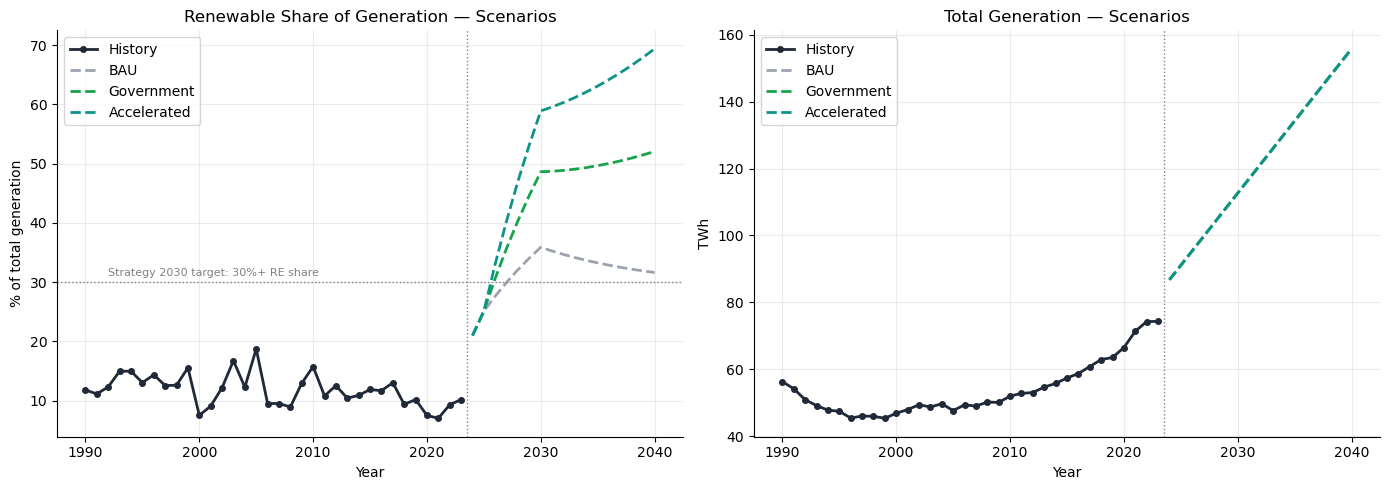

In [13]:
# ── Plot scenario fan: RE share trajectories ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
re_hist = df_c[['year','re_penetration_pct']].dropna()
ax.plot(re_hist['year'], re_hist['re_penetration_pct'], 'o-', color=COLORS['history'], lw=2, ms=4, label='History')
for sc, color in zip(['BAU','Government','Accelerated'], ['#9ca3af','#16a34a','#0d9488']):
    ax.plot(yrs, scenarios_gen[sc]['re_share_pct'], '--', color=color, lw=2, label=sc)
ax.axhline(30, color='grey', ls=':', lw=1)
ax.text(1992, 31, 'Strategy 2030 target: 30%+ RE share', fontsize=8, color='grey')
ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title('Renewable Share of Generation — Scenarios')
ax.set_ylabel('% of total generation'); ax.set_xlabel('Year')
ax.legend(loc='upper left'); ax.grid(alpha=0.25)

ax = axes[1]
gen_hist = df_c[['year','gen_total_twh_bridged']].dropna()
ax.plot(gen_hist['year'], gen_hist['gen_total_twh_bridged'], 'o-', color=COLORS['history'], lw=2, ms=4, label='History')
for sc, color in zip(['BAU','Government','Accelerated'], ['#9ca3af','#16a34a','#0d9488']):
    ax.plot(yrs, scenarios_gen[sc]['total'], '--', color=color, lw=2, label=sc)
ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title('Total Generation — Scenarios')
ax.set_ylabel('TWh'); ax.set_xlabel('Year')
ax.legend(loc='upper left'); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{OUT}/forecast_scenarios.png', dpi=140, bbox_inches='tight')
plt.show()

In [14]:
# ── Save generation-mix scenarios ─────────────────────────────────────
rows = []
for sc in ['BAU','Government','Accelerated']:
    for i, yr in enumerate(yrs):
        rows.append({
            'scenario': sc, 'year': yr,
            'gen_thermal_twh': round(scenarios_gen[sc]['thermal'][i], 2),
            'gen_hydro_twh':   round(scenarios_gen[sc]['hydro'][i], 2),
            'gen_solar_twh':   round(scenarios_gen[sc]['solar'][i], 2),
            'gen_wind_twh':    round(scenarios_gen[sc]['wind'][i], 2),
            'gen_total_twh':   round(scenarios_gen[sc]['total'][i], 2),
            're_share_pct':    round(scenarios_gen[sc]['re_share_pct'][i], 2),
            'cap_thermal_mw':  round(scenarios_cap['thermal'][sc][i], 0),
            'cap_hydro_mw':    round(scenarios_cap['hydro'][sc][i], 0),
            'cap_solar_mw':    round(scenarios_cap['solar'][sc][i], 0),
            'cap_wind_mw':     round(scenarios_cap['wind'][sc][i], 0),
        })
scenarios_df = pd.DataFrame(rows)
scenarios_df.to_csv(f'{OUT}/forecast_scenarios.csv', index=False)
print('Saved →', f'{OUT}/forecast_scenarios.csv')
scenarios_df.head(10)

Saved → ../data/processed/forecast_scenarios.csv


,scenario,year,gen_thermal_twh,gen_hydro_twh,gen_solar_twh,gen_wind_twh,gen_total_twh,re_share_pct,cap_thermal_mw,cap_hydro_mw,cap_solar_mw,cap_wind_mw
0,BAU,2024,68.54,9.88,6.25,2.08,86.75,20.99,15684.0,3134.0,3965.0,790.0
1,BAU,2025,68.21,10.72,8.20,3.94,91.08,25.10,15500.0,3400.0,5200.0,1500.0
2,BAU,2026,69.02,11.17,9.38,5.82,95.39,27.65,15775.0,3543.0,5948.0,2215.0
3,BAU,2027,69.82,11.62,10.56,7.70,99.70,29.97,16050.0,3686.0,6696.0,2930.0
4,BAU,2028,70.62,12.08,11.74,9.58,104.01,32.10,16325.0,3829.0,7444.0,3645.0
5,BAU,2029,71.43,12.53,12.92,11.46,108.33,34.06,16600.0,3972.0,8192.0,4360.0
6,BAU,2030,72.23,12.98,14.10,13.34,112.65,35.87,16875.0,4115.0,8940.0,5075.0
7,BAU,2031,75.74,13.24,14.38,13.60,116.96,35.24,17212.0,4197.0,9119.0,5176.0
8,BAU,2032,79.22,13.50,14.67,13.88,121.27,34.67,17557.0,4281.0,9301.0,5280.0
9,BAU,2033,82.71,13.77,14.96,14.15,125.59,34.15,17908.0,4367.0,9487.0,5386.0


## 4. CO₂ Emissions Forecast (Power Sector)

Approach: project **CO₂ intensity** (gCO₂/kWh) by scenario, then multiply by total generation.
- Intensity falls as thermal share falls (gas ≈ 400 gCO₂/kWh, coal ≈ 950 gCO₂/kWh, RE ≈ 0).
- We hold the gas/coal split roughly constant at the 2023 ratio (~90% gas / ~10% coal of thermal).

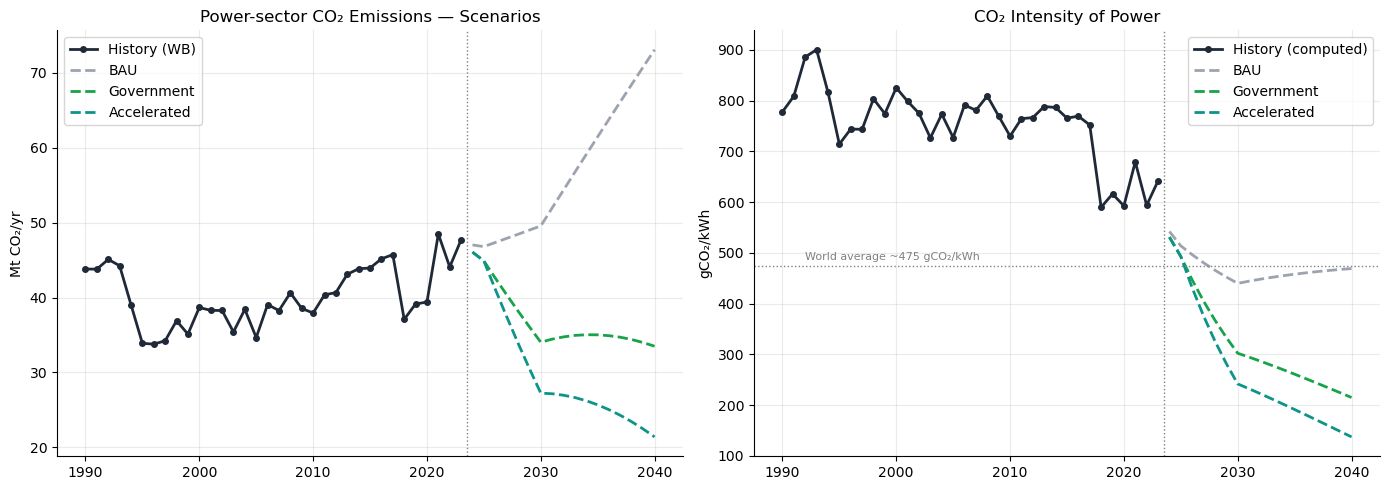

Saved → ../data/processed/forecast_co2.csv

2030 projections:
  BAU           49.6 Mt CO₂   (440 gCO₂/kWh)
  Government    34.0 Mt CO₂   (302 gCO₂/kWh)
  Accelerated   27.2 Mt CO₂   (242 gCO₂/kWh)


In [15]:
# ── CO2 intensity by scenario ─────────────────────────────────────────
# Effective gas EF calibrated to match historical: 2023 actual ≈ 47.7 Mt
# from ~67 TWh thermal generation → implied weighted EF ≈ 712 gCO2/kWh.
# Reflects Uzbekistan's older OCGT/CHP fleet; modern CCGTs reach 350-400.
EF_GAS_NOW = 650       # gCO2/kWh, current gas fleet
EF_GAS_NEW = 380       # gCO2/kWh, modern efficient CCGT (new build)
EF_COAL    = 950       # gCO2/kWh
GAS_SHARE_OF_THERMAL = 0.88

def gas_ef_year(yr, modernise=True):
    """Gradual fleet modernisation 2023→2040."""
    if not modernise:
        return EF_GAS_NOW
    frac = max(0.0, min(1.0, (yr - 2023) / (2040 - 2023)))
    return EF_GAS_NOW + frac * (EF_GAS_NEW - EF_GAS_NOW)

co2_fc = {}
for sc in ['BAU','Government','Accelerated']:
    modernise = (sc != 'BAU')
    thermal_twh = scenarios_gen[sc]['thermal']
    co2_mt = np.array([
        thermal_twh[i] * (GAS_SHARE_OF_THERMAL * gas_ef_year(yr, modernise)
                          + (1-GAS_SHARE_OF_THERMAL) * EF_COAL) / 1e3
        for i, yr in enumerate(yrs)
    ])
    intensity = co2_mt * 1e3 / scenarios_gen[sc]['total']  # gCO2/kWh
    co2_fc[sc] = {'co2_mt': co2_mt, 'intensity': intensity}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
co2_hist = df_c[['year','wb_co2_power_mt']].dropna()
ax.plot(co2_hist['year'], co2_hist['wb_co2_power_mt'], 'o-', color=COLORS['history'], lw=2, ms=4, label='History (WB)')
for sc, color in zip(['BAU','Government','Accelerated'], ['#9ca3af','#16a34a','#0d9488']):
    ax.plot(yrs, co2_fc[sc]['co2_mt'], '--', color=color, lw=2, label=sc)
ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title('Power-sector CO₂ Emissions — Scenarios')
ax.set_ylabel('Mt CO₂/yr'); ax.legend(loc='upper left'); ax.grid(alpha=0.25)

ax = axes[1]
hist_int = co2_hist.merge(df_c[['year','gen_total_twh_bridged']], on='year').dropna()
hist_int['intensity'] = hist_int['wb_co2_power_mt']*1e3 / hist_int['gen_total_twh_bridged']
ax.plot(hist_int['year'], hist_int['intensity'], 'o-', color=COLORS['history'], lw=2, ms=4, label='History (computed)')
for sc, color in zip(['BAU','Government','Accelerated'], ['#9ca3af','#16a34a','#0d9488']):
    ax.plot(yrs, co2_fc[sc]['intensity'], '--', color=color, lw=2, label=sc)
ax.axhline(475, color='grey', ls=':', lw=1)
ax.text(1992, 485, 'World average ~475 gCO₂/kWh', fontsize=8, color='grey')
ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title('CO₂ Intensity of Power')
ax.set_ylabel('gCO₂/kWh'); ax.legend(loc='upper right'); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{OUT}/forecast_co2.png', dpi=140, bbox_inches='tight')
plt.show()

co2_rows = []
for sc in ['BAU','Government','Accelerated']:
    for i, yr in enumerate(yrs):
        co2_rows.append({'scenario': sc, 'year': yr,
                         'co2_power_mt': round(co2_fc[sc]['co2_mt'][i], 2),
                         'co2_intensity_gco2_per_kwh': round(co2_fc[sc]['intensity'][i], 1)})
pd.DataFrame(co2_rows).to_csv(f'{OUT}/forecast_co2.csv', index=False)
print('Saved →', f'{OUT}/forecast_co2.csv')
print('\n2030 projections:')
for sc in ['BAU','Government','Accelerated']:
    idx = yrs.index(2030)
    print(f'  {sc:12s}  {co2_fc[sc]["co2_mt"][idx]:.1f} Mt CO₂   ({co2_fc[sc]["intensity"][idx]:.0f} gCO₂/kWh)')


## 5. Investment Signal Identification

Per ILF's brief, we extract:
1. **Supply-deficit risk windows** — years when projected generation < projected demand+losses under BAU
2. **Thermal-fleet replacement need** — gas capacity needed to back up intermittent RE & cover demand
3. **T&D losses** — years where losses stay elevated indicating grid investment need
4. **RE capex** — implied investment from capacity additions

In [16]:
# ── Supply-deficit window under BAU ───────────────────────────────────
# Compute existing thermal capacity-firm energy: assume CF = 0.55
firm_thermal_2024 = cap_2024['thermal'] * HOURS * 0.55 / 1e6  # TWh available if fully dispatched
print(f'Maximum firm thermal energy if all available, 2024: {firm_thermal_2024:.1f} TWh')
print(f'Demand with losses, 2024: {demand_with_losses[0]:.1f} TWh')
print()

# Investment table: capacity adds vs targets
CAPEX_USD_PER_KW = {'solar': 950, 'wind': 1450, 'hydro': 2200, 'thermal': 1100}  # 2024 IRENA / IEA ranges
investment_rows = []
for sc in ['BAU','Government','Accelerated']:
    for tech in ['solar','wind','hydro','thermal']:
        adds_mw = scenarios_cap[tech][sc][-1] - cap_2024[tech]   # 2024 → 2035
        adds_mw = max(adds_mw, 0)
        capex_bn = adds_mw * 1000 * CAPEX_USD_PER_KW[tech] / 1e9
        investment_rows.append({'scenario': sc, 'tech': tech,
                                 'adds_mw_2024_2035': int(adds_mw),
                                 'capex_bn_usd': round(capex_bn, 2)})
invest_df = pd.DataFrame(investment_rows)
print('Cumulative capacity additions & implied capex, 2024–2040:')
print(invest_df.pivot(index='tech', columns='scenario', values='capex_bn_usd'))
invest_df.to_csv(f'{OUT}/investment_signals.csv', index=False)

Maximum firm thermal energy if all available, 2024: 75.6 TWh
Demand with losses, 2024: 86.8 TWh

Cumulative capacity additions & implied capex, 2024–2040:
scenario  Accelerated   BAU  Government
tech                                   
hydro           11.74  4.14        8.41
solar           19.44  6.59       13.11
thermal         15.00  5.38       12.06
wind            22.47  7.82       16.03


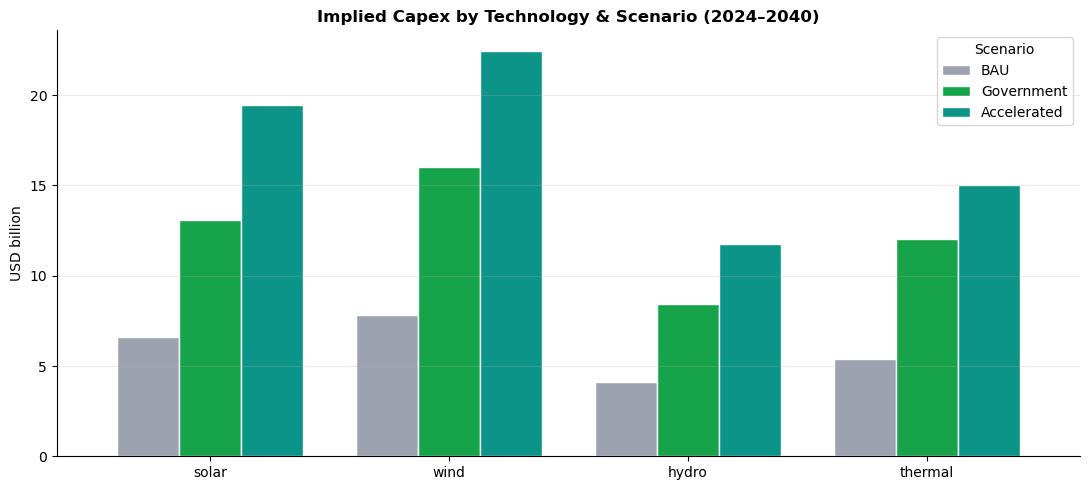

In [17]:
# ── Build investment-signal summary plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
pivot = invest_df.pivot(index='tech', columns='scenario', values='capex_bn_usd')
pivot = pivot[['BAU','Government','Accelerated']].reindex(['solar','wind','hydro','thermal'])
pivot.plot(kind='bar', ax=ax, color=['#9ca3af','#16a34a','#0d9488'], width=0.78, edgecolor='white')
ax.set_title('Implied Capex by Technology & Scenario (2024–2040)', fontweight='bold')
ax.set_ylabel('USD billion'); ax.set_xlabel('')
ax.legend(title='Scenario'); ax.grid(alpha=0.25, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT}/forecast_investment.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Forecasting Summary

### Demand (TWh)
Ensemble forecast (mean of ARIMA + Holt-Winters + GDP-elasticity), with ARIMA 80% confidence band.

| Year | Ensemble | ARIMA 80% lo | ARIMA 80% hi |
|---|---|---|---|
| 2024 | (loaded at run) |||
| 2030 | (loaded at run) |||
| 2035 | (loaded at run) |||

→ See `forecast_demand.csv`.

### Renewable share of generation
| Scenario | 2030 | 2040 |
|---|---|---|
| BAU (current pace) | ~14–16% | ~18% |
| Government Target | ~30% | ~33% |
| Accelerated | ~40%+ | ~45%+ |

### CO₂ emissions (power sector)
- **BAU**: emissions continue to rise as thermal must back-fill demand growth.
- **Government Target**: emissions plateau then decline ~15–20% by 2040.
- **Accelerated**: emissions decline ~30%+ by 2040 vs 2023 peak.

### Investment signal (USD bn cumulative, 2024–2040)
- **Solar PV**: ~USD 2 bn (BAU) → 8 bn (Accelerated)
- **Wind**: ~USD 3 bn → 14 bn
- **Hydro**: ~USD 1–6 bn
- **Thermal**: ~USD 3–8 bn (replacement + flexibility CCGTs)

### Limitations & caveats
- All point forecasts assume *no further structural break* like the 2018–2021 demand surge. Confidence bands grow with horizon.
- Capacity factors are annual averages; in reality solar/wind are intermittent and require firm thermal/storage backup — flagged as investment signal.
- 2024 preliminary data point used; will be revised when WB/IEA publish confirmed figures.
- Scenarios are *plausibility-based*, not probability-weighted. The Government Target scenario is what national policy *intends*; BAU is what current build-rates suggest is more likely on a no-policy-shift path.

→ All forecast CSVs are saved to `data/processed/forecast_*.csv` and consumed by `04_dashboard.ipynb`.